In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Step 2 - Create the dataset
np.random.seed(42)
months = np.arange(1, 49)
sales = 3000 + months * 30 + np.sin(months * np.pi / 6) * 400 + np.random.randint(-150, 150, 48)

df = pd.DataFrame({'month': months, 'sales': sales})
print(df.head(10))

   month        sales
0      1  3182.000000
1      2  3526.410162
2      3  3446.000000
3      4  3387.410162
4      5  3388.000000
5      6  3050.000000
6      7  2962.000000
7      8  2864.589838
8      9  2934.000000
9     10  2890.589838


In [4]:
# Step 3 - Clean the data
# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Add features
df['lag1'] = df['sales'].shift(1)
df['seasonality'] = np.sin(df['month'] * np.pi / 6)
df = df.dropna()

print("Dataset shape:", df.shape)
print(df.head())

Missing values: 0
Dataset shape: (47, 4)
   month        sales         lag1   seasonality
1      2  3526.410162  3182.000000  8.660254e-01
2      3  3446.000000  3526.410162  1.000000e+00
3      4  3387.410162  3446.000000  8.660254e-01
4      5  3388.000000  3387.410162  5.000000e-01
5      6  3050.000000  3388.000000  1.224647e-16


In [5]:
# Step 4 - Train the model
X = df[['month', 'lag1', 'seasonality']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Model trained successfully!
Train size: 37
Test size: 10


In [6]:
# Step 5 - Evaluate accuracy
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score  : {r2:.4f}")
print(f"MAE       : {mae:.2f}")
print(f"RMSE      : {rmse:.2f}")

R² Score  : 0.9651
MAE       : 71.64
RMSE      : 85.56


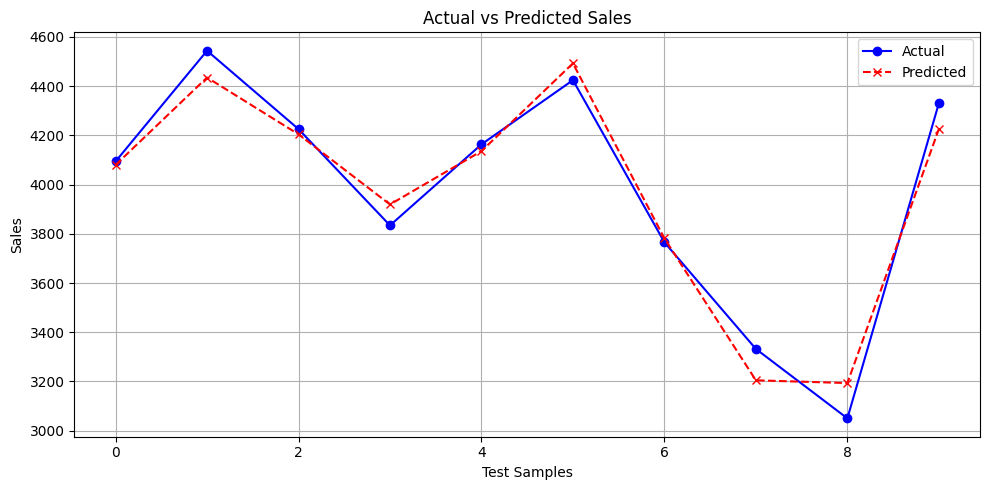

In [7]:
# Step 6 - Visualize Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual', marker='o', color='blue')
plt.plot(y_pred, label='Predicted', marker='x', color='red', linestyle='--')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Test Samples')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

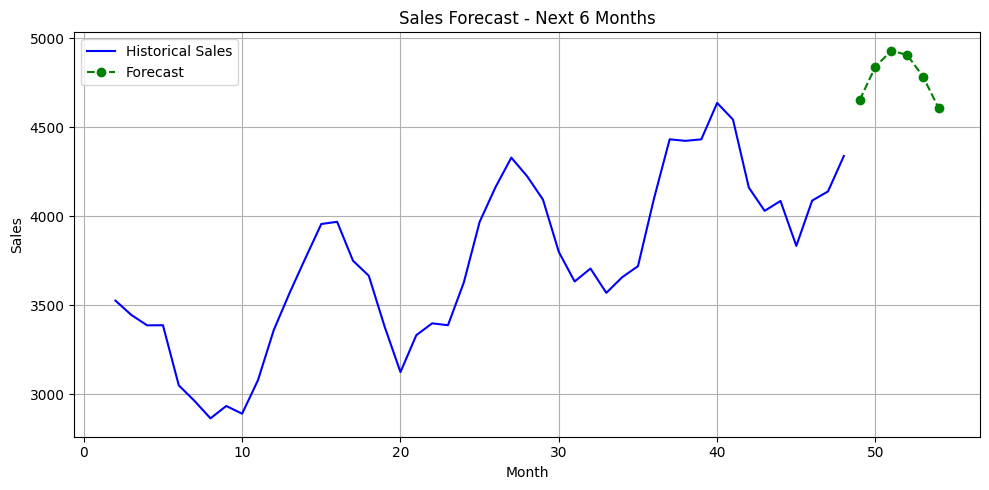

In [9]:
# Step 7 - Forecast next 6 months
last_sale = df['sales'].iloc[-1]
future_months = np.arange(49, 55)
future_preds = []

for m in future_months:
    season = np.sin(m * np.pi / 6)
    input_data = pd.DataFrame([[m, last_sale, season]], columns=['month', 'lag1', 'seasonality'])
    pred = model.predict(input_data)[0]
    future_preds.append(pred)
    last_sale = pred

plt.figure(figsize=(10, 5))
plt.plot(df['month'], df['sales'], label='Historical Sales', color='blue')
plt.plot(future_months, future_preds, label='Forecast', color='green', linestyle='--', marker='o')
plt.title('Sales Forecast - Next 6 Months')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# Final Summary
print("=" * 40)
print("   PREDICTIVE ANALYTICS PROJECT")
print("=" * 40)
print(f"\n Dataset size     : {df.shape[0]} records")
print(f" Features used    : month, lag1, seasonality")
print(f" Model            : Linear Regression")
print(f" Train / Test     : 37 / 10")
print(f"\n--- Model Accuracy ---")
print(f" R² Score         : {r2:.4f}")
print(f" MAE              : {mae:.2f}")
print(f" RMSE             : {rmse:.2f}")
print(f"\n Forecast         : Next 6 months done")
print(f" Visualizations   : 2 charts created")
print("=" * 40)
print(" All task requirements completed!")
print("=" * 40)

   PREDICTIVE ANALYTICS PROJECT

 Dataset size     : 47 records
 Features used    : month, lag1, seasonality
 Model            : Linear Regression
 Train / Test     : 37 / 10

--- Model Accuracy ---
 R² Score         : 0.9651
 MAE              : 71.64
 RMSE             : 85.56

 Forecast         : Next 6 months done
 Visualizations   : 2 charts created
 All task requirements completed!
